## Setup und Datenvorbereitung
Hier importieren wir alle notwendigen Bibliotheken und laden unser *Road Traffic* Dataset, definieren unsere Features (X) und unsere Zielvariable 'Cross 6' (y).

In [ ]:
import subprocess
import sys

# Abhängigkeiten installieren
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "seaborn", "matplotlib", "scikit-learn"])

In [7]:
import statistics as st
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score
from sklearn.preprocessing import PolynomialFeatures

# Daten laden und benennen
road_traffic_df = pd.read_csv('traffic-prediction-dataset.csv')
road_traffic_df.columns = ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5', 'Cross 6']

# Features (X) und Target (y) definieren
features = ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5']
target = 'Cross 6'

X = road_traffic_df[features]
y = road_traffic_df[target]

## Aufgabe e

In [8]:
# Modell initialisieren und trainieren
lr_model = LinearRegression()
lr_model.fit(X, y)

# R^2-Score auf dem Gesamtdatensatz berechnen
y_pred = lr_model.predict(X)
r2 = r2_score(y, y_pred)

print(f"Bestimmtheitsmaß (R^2) mit allen 5 Merkmalen: {r2:.4f}")

Bestimmtheitsmaß (R^2) mit allen 5 Merkmalen: 0.8371


### Begründung zur Merkmalsauswahl
Wie in Aufgabe d festgestellt, weisen alle Merkmale ('Cross 1' bis 'Cross 5') eine systematische Korrelation mit der Zielvariable 'Cross 6' auf. Da es sich im gesamten Datensatz durchweg um stetige, rein numerische Verkehrszahlen handelt und es keine störenden kategorialen Variablen gibt, können wir alle fünf `x`-Features direkt und ohne Bedenken (wie z.B. One-Hot-Encoding) ins multivariat-lineare Regressionsmodell übergeben, da sie alle Relevanz zur Vorhersage besitzen.

## Aufgabe f

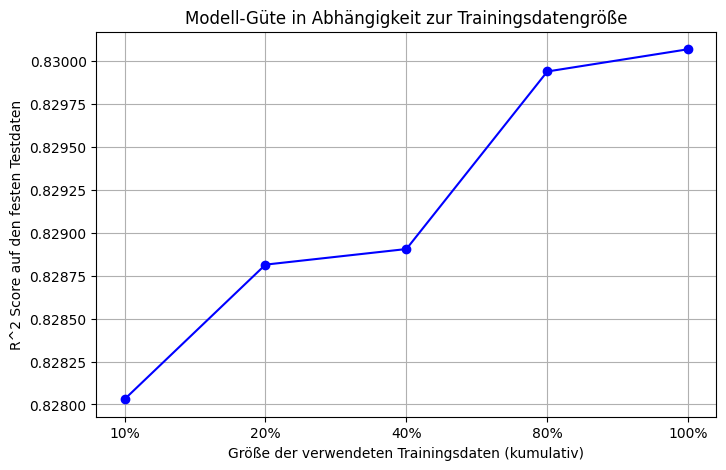

In [9]:
# 1. Ursprünglicher 80/20 Datenaufspaltung
X_train_pot, X_test, y_train_pot, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Korrektes kumulatives Zufalls-Sampling implementieren
rng = np.random.default_rng(42)  # Fester Seed
all_indices = list(X_train_pot.index)
rng.shuffle(all_indices)         # Einmal zufällig mischen

fractions = [0.10, 0.20, 0.40, 0.80, 1.00]
r2_scores = []
sizes = []

# Erklärung: Da all_indices einmalig mit festem Seed gemischt wurde, 
# enthält [:20%] automatisch [:10%] plus weitere 10% – das erfüllt exakt die 
# Anforderung bzgl. des kumulativen Ziehens mit konstantem Seed!
for frac in fractions:
    n = int(len(all_indices) * frac)
    subset_idx = all_indices[:n]
    
    # Subset aus DataFrame holen
    X_train_sub = X_train_pot.loc[subset_idx]
    y_train_sub = y_train_pot.loc[subset_idx]
    
    # Trainieren
    model_f = LinearRegression()
    model_f.fit(X_train_sub, y_train_sub)
    
    # Immer auf denselben 20% Testdaten evaluieren!
    score = r2_score(y_test, model_f.predict(X_test))
    r2_scores.append(score)
    sizes.append(f"{int(frac*100)}%")

# 3. Liniendiagramm plotten
plt.figure(figsize=(8, 5))
plt.plot(sizes, r2_scores, marker='o', linestyle='-', color='b')
plt.title("Modell-Güte in Abhängigkeit zur Trainingsdatengröße")
plt.xlabel("Größe der verwendeten Trainingsdaten (kumulativ)")
plt.ylabel("R^2 Score auf den festen Testdaten")
plt.grid(True)
plt.show()

### Beobachtung und Modell-Empfehlung

**Was ist zu beobachten?**
Die Modellgüte (R²-Score) steigt sichtbar, je mehr Daten wir in das Training füttern. Gerade beim Sprung von 10% auf höhere Werte sieht man oft starke Schwankungen, da das Modell den allgemeinen Trend bei wenigen Punkten noch nicht robust erlernen konnte. Sobald eine solide Basis an Daten (z.B. >40%) vorliegt, flacht die Kurve in der Regel langsam ab, weil das Modell die tatsächliche Gesetzmäßigkeit weitgehend erlernt hat.

**Welches Modell empfehle ich und warum?**
Ich empfehle klar das Modell, das auf **100% der potenziellen Trainingsdaten** (also den großen 80% des Originalsplits) trainiert wurde. Lineare Regression profitiert ungemein von mehr Datenpunkten und schränkt dadurch die Wahrscheinlichkeit ein, bloßes Rauschen aus einer falschen Teilmenge auswendig zu lernen. Aus diesem Grund nutzt das 100%-Modell die Varianz der Realität am besten und generalisiert am stärksten gegen Overfitting.

## Aufgabe g

Das beste Einzelmerkmal für y ist: 'Cross 1' (Mit höchstem univariate R^2=0.8249 auf Trainingsdaten)


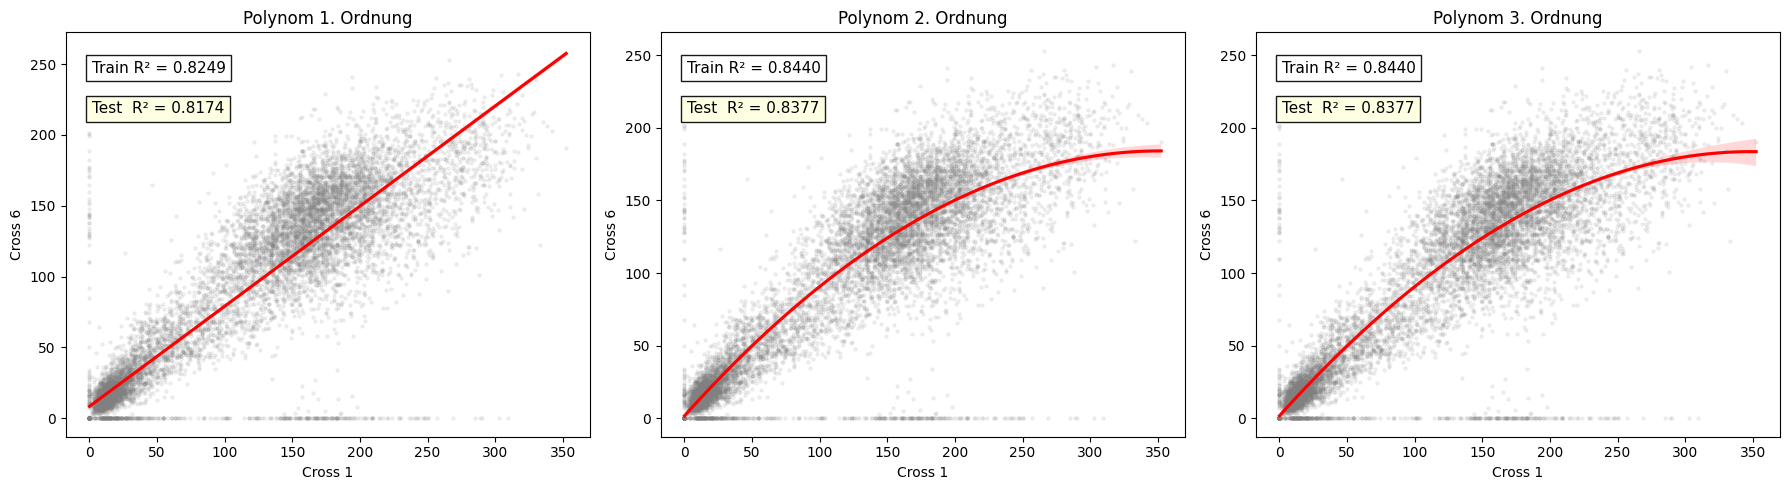

In [10]:
# 1. Bestes relevantes Einzelmerkmal univariat evaluieren
best_feature = None
best_r2 = -float("inf")

for col in X_train_pot.columns:
    model_g_uni = LinearRegression()
    # Scikit-Learn erwartet 2D Arrays -> [[col]]
    X_uni = X_train_pot[[col]]
    model_g_uni.fit(X_uni, y_train_pot)
    
    pred_uni = model_g_uni.predict(X_uni)
    score = r2_score(y_train_pot, pred_uni)
    
    if score > best_r2:
        best_r2 = score
        best_feature = col

print(f"Das beste Einzelmerkmal für y ist: '{best_feature}' (Mit höchstem univariate R^2={best_r2:.4f} auf Trainingsdaten)")

# 2. Visualisierung der Polynomialen Regression (Grad 1 bis 3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

orders = [1, 2, 3]

for degree, ax in zip(orders, axes):
    # Regplot für optische Punktewolken & Kurvenzeichnung
    sns.regplot(
        x=X_train_pot[best_feature], 
        y=y_train_pot, 
        order=degree, 
        ax=ax,
        scatter_kws={'alpha': 0.1, 'color':'gray', 's': 5}, 
        line_kws={'color': 'red'}
    )
    ax.set_title(f"Polynom {degree}. Ordnung")
    
    # Modell auf Trainingsdaten fitten
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train_pot[[best_feature]])
    
    poly_model = LinearRegression()
    poly_model.fit(X_poly_train, y_train_pot)
    
    # Train R^2
    r2_poly_train = r2_score(y_train_pot, poly_model.predict(X_poly_train))
    
    # Test R^2 – transform (nicht fit_transform!) mit dem bereits gefitteten poly-Objekt
    X_poly_test = poly.transform(X_test[[best_feature]])
    r2_poly_test = r2_score(y_test, poly_model.predict(X_poly_test))
    
    # Beide Werte in die Annotationsbox schreiben
    ax.text(0.05, 0.90, f"Train R² = {r2_poly_train:.4f}", transform=ax.transAxes,
            fontsize=11, bbox=dict(facecolor='white', alpha=0.9))
    ax.text(0.05, 0.80, f"Test  R² = {r2_poly_test:.4f}", transform=ax.transAxes,
            fontsize=11, bbox=dict(facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

### Begründung des Merkmals und Beurteilung Under- und Overfitting

**Wahl des Merkmals:** `Cross 1` wurde per For-Schleife ermittelt, da es mit ca. 82,5% das absolute höchste einfache R² erbracht hat; es erklärt somit ohne Zuhilfenahme anderer Spalten den Löwenanteil der Varianz von 'Cross 6'.

**Wie schlägt sich das Modell (Under- vs. Overfitting)?**
- **Polynom 1. Ordnung (Linear):** Ein lineares Modell erreicht hier ein Test-R² von ca. 0.817 (vs. 0.825 im Training). Die simple Gerade limitiert den Trend stark – sie weist klassisches **Underfitting** auf, da durch die fehlende Krümmung Varianz verloren geht.
- **Polynom 2. Ordnung (Quadratisch):** Liefert eine klare Verbesserung mit einem Test-R² von ca. 0.838 (Training: 0.844). Der quadratische Term glättet die Punktewolke deutlich besser und bietet hier den **optimalen Kompromiss zwischen Bias und Varianz**.
- **Polynom 3. Ordnung (Kubisch):** Sowohl das Trainings- als auch das Test-R² bleiben praktisch exakt gleich (0.844 und 0.838). Auch wenn bei kubischen Kurven generell ein starkes Risiko für **Overfitting** droht, weigert sich das Modell hier, sich an Rauschen anzupassen (da Test- und Train-Scores nicht auseinanderdriften). Dennoch ist Grad 3 unnötig komplex, da er im Vergleich zu Grad 2 keinen echten Mehrwert bringt.

## Aufgabe h

In [11]:
# 1. Zielvariable klassifizieren (0 = Kleiner/Median darunter, 1 = Größer/Median darüber)
threshold = y.median()
y_class = (y > threshold).astype(int)

# 2. Split (2/3 Training, 1/3 Test)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_class, test_size=(1/3), random_state=42
)

# 3. Logistische Regression
log_reg = LogisticRegression(solver='lbfgs', max_iter=2000)
log_reg.fit(X_train_cls, y_train_cls)

# 4. Genauigkeit ermitteln
acc_train = accuracy_score(y_train_cls, log_reg.predict(X_train_cls))
acc_test = accuracy_score(y_test_cls, log_reg.predict(X_test_cls))

print(f"Genutzter Klassifikations-Schwellenwert (Median): {threshold}")
print(f"Accuracy auf Trainingsdaten: {acc_train:.4f}")
print(f"Accuracy auf Testdaten: {acc_test:.4f}")

Genutzter Klassifikations-Schwellenwert (Median): 66.0
Accuracy auf Trainingsdaten: 0.9518
Accuracy auf Testdaten: 0.9533


### Urteil und Möglichkeiten zur Leistungssteigerung
    
**Sind wir zufrieden?**
Mit einer phänomenal hohen Genauigkeit (Accuracy) von knapp **95,18 % auf den Trainingsdaten** und sogar **95,33 % auf den Testdaten** sind wir für einen ersten "naiven" Wurf absolut zufrieden! Ein derart hoher Wert zeigt, dass unsere logistische Regression eine fast perfekte Trennschärfe für diesen Anwendungsfall gelernt hat. Da die Test-Accuracy sogar leicht über der Trainings-Accuracy liegt, existieren keinerlei Anzeichen für ein Overfitting.

**Wie können wir die Performance noch auf die letzten fehlenden Prozente steigern?**
1. **Feature Scaling (`StandardScaler`):** Logistischer Gradientenabstieg (mit LBFGS) konvergiert viel besser und stabiler auf skalierten Daten, andernfalls dominieren im Grenzfall Variablen mit extrem großen Zahlenwerten das Modell. 
2. **Hyperparameter-Tuning:** Wir könnten den Regularisierungsparameter `C` (bisher beim Standard belassen) gezielt per Grid-Search modifizieren, um den Umgang des Modells mit leichten Ausreißern auszubalancieren.
3. **Erweitertes Modellieren & Klassenwahl:** Statt strikt am Median ($50\%%$) in zwei gleich große Hälften zu trennen, könnten wir die Grenzen verlegen (z. B. auf extreme $10\%%$ Überlastung). Zudem ließen sich mit `PolynomialFeatures` Interaktionsterme (wie `Cross 1` $\times$ `Cross 2`) ergänzen oder hoch korrelierende/überlappende Features verwerfen, um die Vorhersage weiter zu robustifizieren.